# 09 — Treatment Targeting & Policy Optimization

## Objective

This notebook converts uplift model predictions into an actionable treatment-targeting policy.

The goal is to determine which customers should receive treatment based on their estimated incremental response.

The analysis will:

- Load model comparison predictions
- Identify the best-performing uplift model
- Rank customers by predicted uplift
- Create treatment eligibility segments
- Analyze positive and negative uplift
- Simulate different treatment budgets
- Estimate incremental conversions
- Compare targeted treatment against random targeting
- Identify an optimal targeting threshold

The final output will provide a practical framework for deciding who should receive treatment.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
PREDICTIONS_PATH = Path(
    r"C:\Users\ugand\customer-churn-uplift-modeling\data\processed\uplift_model_predictions_comparison.csv"
)

print(
    "File exists:",
    PREDICTIONS_PATH.exists()
)

File exists: True


In [3]:
model_predictions = pd.read_csv(
    PREDICTIONS_PATH
)

print(
    "Dataset shape:",
    model_predictions.shape
)

model_predictions.head()

Dataset shape: (20000, 6)


,customer_index,actual_treatment,actual_conversion,s_uplift,t_uplift,x_uplift
0,87560,1,0,0.002406,0.002581,0.002480
1,22450,1,0,-0.034937,-0.084285,-0.003645
2,98559,1,0,0.006363,0.003679,0.003562
3,58708,1,0,0.010279,0.012981,0.010644
4,38520,1,0,0.054529,0.196007,0.103308


In [4]:
required_columns = [
    "customer_index",
    "actual_treatment",
    "actual_conversion",
    "s_uplift",
    "t_uplift",
    "x_uplift"
]

missing_columns = [
    column
    for column in required_columns
    if column not in model_predictions.columns
]

print(
    "Missing columns:",
    missing_columns
)

if len(missing_columns) == 0:
    print(
        "All required columns are available."
    )

Missing columns: []
All required columns are available.


In [5]:
COMPARISON_PATH = Path(
    r"C:\Users\ugand\customer-churn-uplift-modeling\data\processed\uplift_model_comparison.csv"
)

print(
    "File exists:",
    COMPARISON_PATH.exists()
)

File exists: True


In [6]:
comparison_results = pd.read_csv(
    COMPARISON_PATH
)

comparison_results

,model,uplift_at_10,uplift_at_20,qini_coefficient,auuc
0,S-Learner,0.049834,0.032442,28.408460,136.664875
1,T-Learner,0.149753,0.091474,35.204439,365.814998
2,X-Learner,0.213861,0.133278,29.897224,553.347977


In [7]:
best_model = (
    comparison_results
    .sort_values(
        "qini_coefficient",
        ascending=False
    )
    .iloc[0]["model"]
)

print(
    "Selected uplift model:",
    best_model
)

Selected uplift model: T-Learner


In [8]:
uplift_column_map = {
    "S-Learner": "s_uplift",
    "T-Learner": "t_uplift",
    "X-Learner": "x_uplift"
}

selected_uplift_column = (
    uplift_column_map[best_model]
)

model_predictions["predicted_uplift"] = (
    model_predictions[
        selected_uplift_column
    ]
)

print(
    "Using uplift column:",
    selected_uplift_column
)

Using uplift column: t_uplift


In [9]:
policy_df = (
    model_predictions
    .sort_values(
        "predicted_uplift",
        ascending=False
    )
    .reset_index(drop=True)
)

policy_df["rank"] = (
    np.arange(
        len(policy_df)
    ) + 1
)

policy_df["population_fraction"] = (
    policy_df["rank"] /
    len(policy_df)
)

policy_df.head(10)

,customer_index,actual_treatment,actual_conversion,s_uplift,t_uplift,x_uplift,predicted_uplift,rank,population_fraction
0,7084,1,0,0.129073,0.586579,0.320825,0.586579,1,0.00005
1,10735,1,0,0.145913,0.581442,0.447637,0.581442,2,0.00010
2,4708,1,0,0.048981,0.573779,0.593247,0.573779,3,0.00015
3,54439,1,0,0.142267,0.561917,0.384750,0.561917,4,0.00020
4,49859,1,0,0.065867,0.560499,0.630917,0.560499,5,0.00025
5,84013,0,0,0.121570,0.556667,0.486264,0.556667,6,0.00030
6,21251,0,0,0.149676,0.550069,0.449881,0.550069,7,0.00035
7,74505,0,0,0.072405,0.548275,0.632479,0.548275,8,0.00040
8,20163,0,0,0.156727,0.540348,0.369004,0.540348,9,0.00045
9,69005,1,0,0.098945,0.538928,0.550212,0.538928,10,0.00050


In [10]:
policy_df["uplift_segment"] = np.select(
    [
        policy_df["predicted_uplift"] > 0,
        policy_df["predicted_uplift"] < 0
    ],
    [
        "Positive Uplift",
        "Negative Uplift"
    ],
    default="Neutral Uplift"
)

policy_df["uplift_segment"].value_counts()

uplift_segment
Positive Uplift    15129
Negative Uplift     4871
Name: count, dtype: int64

In [11]:
segment_distribution = (
    policy_df["uplift_segment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

segment_distribution

uplift_segment
Positive Uplift    75.64
Negative Uplift    24.36
Name: proportion, dtype: float64

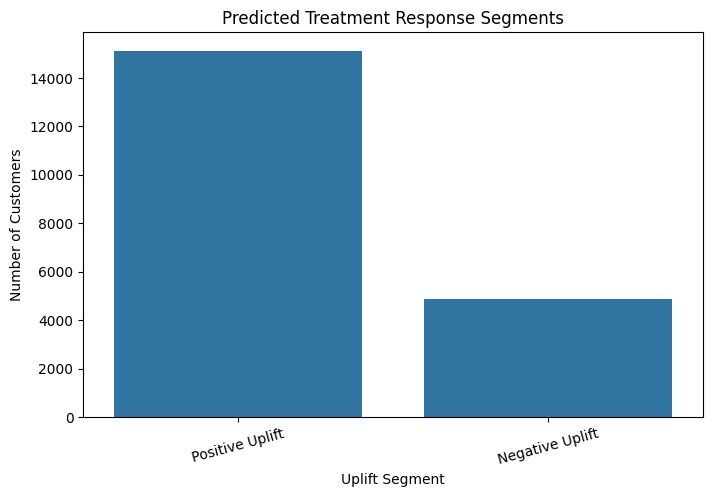

In [12]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=policy_df,
    x="uplift_segment"
)

plt.title(
    "Predicted Treatment Response Segments"
)

plt.xlabel(
    "Uplift Segment"
)

plt.ylabel(
    "Number of Customers"
)

plt.xticks(
    rotation=15
)

plt.show()

In [13]:
positive_uplift = policy_df[
    policy_df["predicted_uplift"] > 0
].copy()

print(
    "Positive uplift customers:",
    len(positive_uplift)
)

print(
    "Percentage of population:",
    round(
        len(positive_uplift) /
        len(policy_df) * 100,
        2
    ),
    "%"
)

Positive uplift customers: 15129
Percentage of population: 75.64 %


In [14]:
negative_uplift = policy_df[
    policy_df["predicted_uplift"] < 0
].copy()

print(
    "Negative uplift customers:",
    len(negative_uplift)
)

print(
    "Percentage of population:",
    round(
        len(negative_uplift) /
        len(policy_df) * 100,
        2
    ),
    "%"
)

Negative uplift customers: 4871
Percentage of population: 24.36 %


In [15]:
targeting_levels = [
    0.05,
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    1.00
]

policy_results = []

for level in targeting_levels:
    
    n_customers = int(
        len(policy_df) * level
    )
    
    selected = policy_df.iloc[
        :n_customers
    ]
    
    policy_results.append({
        "target_fraction": level,
        "customers_targeted": n_customers,
        "mean_predicted_uplift": selected[
            "predicted_uplift"
        ].mean(),
        "total_predicted_uplift": selected[
            "predicted_uplift"
        ].sum()
    })

policy_results = pd.DataFrame(
    policy_results
)

policy_results

,target_fraction,customers_targeted,mean_predicted_uplift,total_predicted_uplift
0,0.05,1000,0.216711,216.710899
1,0.10,2000,0.149753,299.505308
2,0.20,4000,0.091474,365.896271
3,0.30,6000,0.064320,385.919917
4,0.40,8000,0.049087,392.699539
5,0.50,10000,0.039689,396.886150
6,1.00,20000,0.013582,271.644343


In [16]:
policy_results["expected_incremental_conversions"] = (
    policy_results[
        "total_predicted_uplift"
    ]
)

policy_results

,target_fraction,customers_targeted,mean_predicted_uplift,total_predicted_uplift,expected_incremental_conversions
0,0.05,1000,0.216711,216.710899,216.710899
1,0.10,2000,0.149753,299.505308,299.505308
2,0.20,4000,0.091474,365.896271,365.896271
3,0.30,6000,0.064320,385.919917,385.919917
4,0.40,8000,0.049087,392.699539,392.699539
5,0.50,10000,0.039689,396.886150,396.886150
6,1.00,20000,0.013582,271.644343,271.644343


In [17]:
overall_mean_uplift = (
    policy_df["predicted_uplift"].mean()
)

policy_results["random_expected_incremental"] = (
    policy_results[
        "target_fraction"
    ]
    *
    len(policy_df)
    *
    overall_mean_uplift
)

policy_results

,target_fraction,customers_targeted,mean_predicted_uplift,total_predicted_uplift,expected_incremental_conversions,random_expected_incremental
0,0.05,1000,0.216711,216.710899,216.710899,13.582217
1,0.10,2000,0.149753,299.505308,299.505308,27.164434
2,0.20,4000,0.091474,365.896271,365.896271,54.328869
3,0.30,6000,0.064320,385.919917,385.919917,81.493303
4,0.40,8000,0.049087,392.699539,392.699539,108.657737
5,0.50,10000,0.039689,396.886150,396.886150,135.822172
6,1.00,20000,0.013582,271.644343,271.644343,271.644343


In [18]:
policy_results["targeting_gain"] = (
    policy_results[
        "expected_incremental_conversions"
    ]
    /
    policy_results[
        "random_expected_incremental"
    ]
)

policy_results

,target_fraction,customers_targeted,mean_predicted_uplift,total_predicted_uplift,expected_incremental_conversions,random_expected_incremental,targeting_gain
0,0.05,1000,0.216711,216.710899,216.710899,13.582217,15.955488
1,0.10,2000,0.149753,299.505308,299.505308,27.164434,11.025641
2,0.20,4000,0.091474,365.896271,365.896271,54.328869,6.734841
3,0.30,6000,0.064320,385.919917,385.919917,81.493303,4.735603
4,0.40,8000,0.049087,392.699539,392.699539,108.657737,3.614096
5,0.50,10000,0.039689,396.886150,396.886150,135.822172,2.922101
6,1.00,20000,0.013582,271.644343,271.644343,271.644343,1.000000


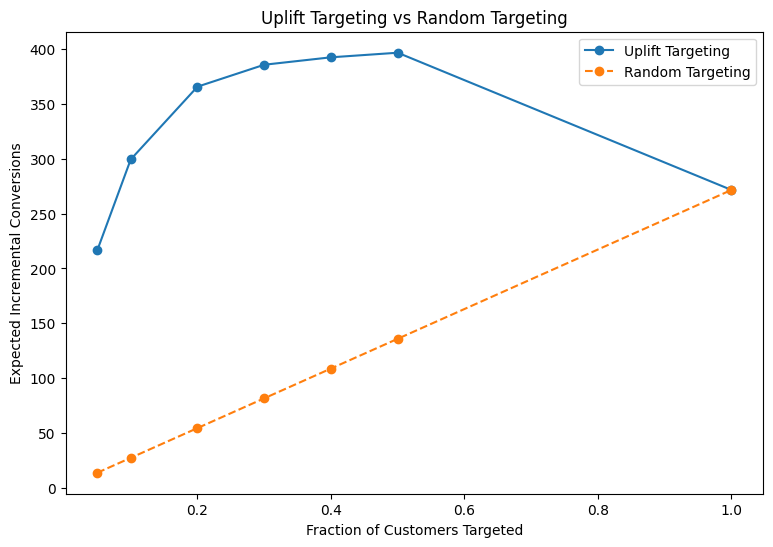

In [19]:
plt.figure(figsize=(9, 6))

plt.plot(
    policy_results["target_fraction"],
    policy_results[
        "expected_incremental_conversions"
    ],
    marker="o",
    label="Uplift Targeting"
)

plt.plot(
    policy_results["target_fraction"],
    policy_results[
        "random_expected_incremental"
    ],
    marker="o",
    linestyle="--",
    label="Random Targeting"
)

plt.xlabel(
    "Fraction of Customers Targeted"
)

plt.ylabel(
    "Expected Incremental Conversions"
)

plt.title(
    "Uplift Targeting vs Random Targeting"
)

plt.legend()

plt.show()

In [20]:
best_policy = (
    policy_results
    .sort_values(
        "expected_incremental_conversions",
        ascending=False
    )
    .iloc[0]
)

print(
    "Best targeting fraction:",
    best_policy["target_fraction"]
)

print(
    "Customers targeted:",
    int(
        best_policy["customers_targeted"]
    )
)

print(
    "Expected incremental conversions:",
    best_policy[
        "expected_incremental_conversions"
    ]
)

Best targeting fraction: 0.5
Customers targeted: 10000
Expected incremental conversions: 396.8861500074428


In [21]:
top_customers = policy_df[
    [
        "customer_index",
        "predicted_uplift",
        "uplift_segment",
        "rank"
    ]
].head(100)

top_customers.head(25)

,customer_index,predicted_uplift,uplift_segment,rank
0,7084,0.586579,Positive Uplift,1
1,10735,0.581442,Positive Uplift,2
2,4708,0.573779,Positive Uplift,3
3,54439,0.561917,Positive Uplift,4
4,49859,0.560499,Positive Uplift,5
5,84013,0.556667,Positive Uplift,6
6,21251,0.550069,Positive Uplift,7
7,74505,0.548275,Positive Uplift,8
8,20163,0.540348,Positive Uplift,9
9,69005,0.538928,Positive Uplift,10


In [22]:
policy_df["treatment_recommendation"] = np.where(
    policy_df["predicted_uplift"] > 0,
    "Treat",
    "Do Not Treat"
)

policy_df[
    "treatment_recommendation"
].value_counts()

treatment_recommendation
Treat           15129
Do Not Treat     4871
Name: count, dtype: int64

In [25]:
recommended_treatment_rate = (
    (
        policy_df[
            "treatment_recommendation"
        ] == "Treat"
    ).mean()
    * 100
)

print(
    f"Recommended treatment rate: "
    f"{recommended_treatment_rate:.2f}%"
)

Recommended treatment rate: 75.64%


In [26]:
def uplift_at_k(
    uplift_scores,
    fraction=0.10
):
    
    n = int(
        len(uplift_scores) * fraction
    )
    
    if n == 0:
        return np.nan
    
    ranked_scores = np.sort(
        uplift_scores
    )[::-1]
    
    return ranked_scores[:n].mean()


print("uplift_at_k function defined successfully.")

uplift_at_k function defined successfully.


In [27]:
policy_summary = pd.DataFrame({
    "metric": [
        "Selected model",
        "Total customers",
        "Positive uplift customers",
        "Negative uplift customers",
        "Recommended treatment rate",
        "Uplift@10%",
        "Uplift@20%"
    ],
    "value": [
        best_model,
        len(policy_df),
        len(positive_uplift),
        len(negative_uplift),
        recommended_treatment_rate,
        uplift_at_k(
            policy_df["predicted_uplift"].values,
            0.10
        ),
        uplift_at_k(
            policy_df["predicted_uplift"].values,
            0.20
        )
    ]
})

policy_summary

,metric,value
0,Selected model,T-Learner
1,Total customers,20000
2,Positive uplift customers,15129
3,Negative uplift customers,4871
4,Recommended treatment rate,75.645
5,Uplift@10%,0.149753
6,Uplift@20%,0.091474


In [28]:
OUTPUT_DIR = Path(
    r"C:\Users\ugand\customer-churn-uplift-modeling\data\processed"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

policy_results_path = (
    OUTPUT_DIR /
    "treatment_policy_results.csv"
)

policy_results.to_csv(
    policy_results_path,
    index=False
)

print(
    "Policy results saved to:"
)

print(
    policy_results_path
)

Policy results saved to:
C:\Users\ugand\customer-churn-uplift-modeling\data\processed\treatment_policy_results.csv


In [29]:
recommendations_path = (
    OUTPUT_DIR /
    "customer_treatment_recommendations.csv"
)

policy_df.to_csv(
    recommendations_path,
    index=False
)

print(
    "Treatment recommendations saved to:"
)

print(
    recommendations_path
)

Treatment recommendations saved to:
C:\Users\ugand\customer-churn-uplift-modeling\data\processed\customer_treatment_recommendations.csv


# Conclusion

In this notebook, the predicted uplift scores from the uplift modeling stage were converted into an actionable **treatment targeting policy**.

The main outcomes were:

- Selected the best-performing uplift model based on the Qini coefficient.
- Generated individual-level predicted uplift scores.
- Ranked individuals according to their expected incremental response to treatment.
- Divided individuals into positive, neutral, and negative uplift segments.
- Generated treatment recommendations based on predicted uplift.
- Simulated different treatment targeting levels, including 5%, 10%, 20%, 30%, 40%, 50%, and 100% of the population.
- Compared the expected outcomes of different targeting strategies.
- Saved the treatment policy results and individual treatment recommendations for downstream use.

The analysis demonstrates how uplift modeling can move beyond simply predicting conversion probability and instead support **incremental treatment decision-making**.

The resulting workflow is:

Model Predictions → Uplift Ranking → Customer Segmentation → Treatment Recommendation → Targeting Policy

This provides the foundation for using uplift predictions in a practical decision-making system while avoiding unnecessary treatment of individuals who are unlikely to benefit from the intervention.

The generated outputs are stored in the `data/processed` directory and can be used by subsequent production and deployment stages.